# 🍄 Mushroom Edibility: Model Benchmarking
### Phase 2 (standardized pipeline + benchmarking) and Phase 4 (cross-dataset comparison)

Educational / ML benchmark exercise — not a foraging safety tool (see the EDA notebook for
the full caveat).

This notebook trains the same five model families on **both** the classic and secondary
datasets, using a standardized preprocessing pipeline, and compares:
- Accuracy, Precision, Recall, F1, ROC-AUC (test set + 5-fold CV)
- Confusion matrices
- Training time and prediction time
- Feature importance / coefficients

Models: **Logistic Regression** (linear baseline), **Decision Tree** (interpretable rules),
**Random Forest** (nonlinear interactions), **XGBoost** and **LightGBM** (high-performance
boosting), and **CatBoost** (native categorical handling).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import mushroom_lib as ml

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

RANDOM_STATE = ml.RANDOM_STATE


In [2]:
def build_model_dict():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
        "LightGBM": LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    }


def run_benchmark(df, dataset_name):
    """Standardized train/test split, preprocessing, and evaluation for all 6 models."""
    numeric_cols, categorical_cols = ml.split_feature_types(df)
    X_raw = df[numeric_cols + categorical_cols]
    y = df["class"]

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    pre = ml.make_onehot_preprocessor(numeric_cols, categorical_cols)
    X_train = pre.fit_transform(X_train_raw)
    X_test = pre.transform(X_test_raw)
    feature_names = pre.get_feature_names_out()

    results, fitted_models = [], {}
    for name, est in build_model_dict().items():
        res, fitted = ml.evaluate_model(name, est, X_train, X_test, y_train, y_test, do_cv=True)
        results.append(res)
        fitted_models[name] = fitted

    # CatBoost: native categorical handling, no one-hot
    Xc_train, cat_idx = ml.prep_for_catboost(X_train_raw, numeric_cols, categorical_cols)
    Xc_test, _ = ml.prep_for_catboost(X_test_raw, numeric_cols, categorical_cols)
    cb_factory = lambda: CatBoostClassifier(iterations=150, verbose=0, random_state=RANDOM_STATE,
                                             cat_features=cat_idx)
    cb = cb_factory()
    res, fitted = ml.evaluate_model("CatBoost", cb, Xc_train, Xc_test, y_train, y_test, do_cv=True,
                                     estimator_factory=cb_factory)
    results.append(res)
    fitted_models["CatBoost"] = fitted

    print(f"\n=== {dataset_name}: {len(y_train):,} train / {len(y_test):,} test rows, "
          f"{X_train.shape[1]} one-hot features ===")

    return {
        "results": results,
        "models": fitted_models,
        "X_test": X_test, "y_test": y_test,
        "Xc_test": Xc_test,
        "feature_names": feature_names,
        "numeric_cols": numeric_cols, "categorical_cols": categorical_cols,
    }


## Run the standardized benchmark on both datasets

This runs all 6 models with 5-fold cross-validation on each dataset. Random Forest and
CatBoost are the slowest to fit; expect this cell to take a few minutes on a single CPU
core.

In [3]:
classic = ml.load_classic()
secondary = ml.load_secondary()

bench = {}
bench["Classic"] = run_benchmark(classic, "Classic")
bench["Secondary"] = run_benchmark(secondary, "Secondary")



=== Classic: 6,499 train / 1,625 test rows, 117 one-hot features ===



=== Secondary: 48,855 train / 12,214 test rows, 128 one-hot features ===


## Results tables

In [4]:
for dsname, b in bench.items():
    print(f"\n{dsname} dataset — held-out test set + 5-fold CV")
    display(ml.results_to_frame(b["results"]).round(4))



Classic dataset — held-out test set + 5-fold CV


,accuracy,precision,recall,f1,roc_auc,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean,train_time_s,predict_time_s
model,,,,,,,,,,
Logistic Regression,0.9994,1.0,0.9987,0.9994,1.0,0.9994,0.9994,1.0000,0.0146,0.0002
Decision Tree,1.0000,1.0,1.0000,1.0000,1.0,0.9997,0.9997,0.9997,0.0126,0.0004
Random Forest,1.0000,1.0,1.0000,1.0000,1.0,1.0000,1.0000,1.0000,0.5020,0.0180
XGBoost,1.0000,1.0,1.0000,1.0000,1.0,1.0000,1.0000,1.0000,0.0765,0.0037
LightGBM,1.0000,1.0,1.0000,1.0000,1.0,1.0000,1.0000,1.0000,0.1211,0.0090
CatBoost,1.0000,1.0,1.0000,1.0000,1.0,0.9997,0.9997,1.0000,1.1091,0.0074



Secondary dataset — held-out test set + 5-fold CV


,accuracy,precision,recall,f1,roc_auc,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean,train_time_s,predict_time_s
model,,,,,,,,,,
Logistic Regression,0.8643,0.8762,0.8796,0.8779,0.9369,0.8661,0.8785,0.9367,0.4047,0.0008
Decision Tree,0.9992,0.9994,0.9991,0.9993,0.9992,0.9987,0.9988,0.9987,0.8065,0.0021
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,21.2119,0.1676
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7893,0.0714
LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0517,0.1521
CatBoost,0.9996,0.9994,0.9999,0.9996,1.0000,0.9997,0.9997,1.0000,6.8281,0.0431


## Confusion matrices

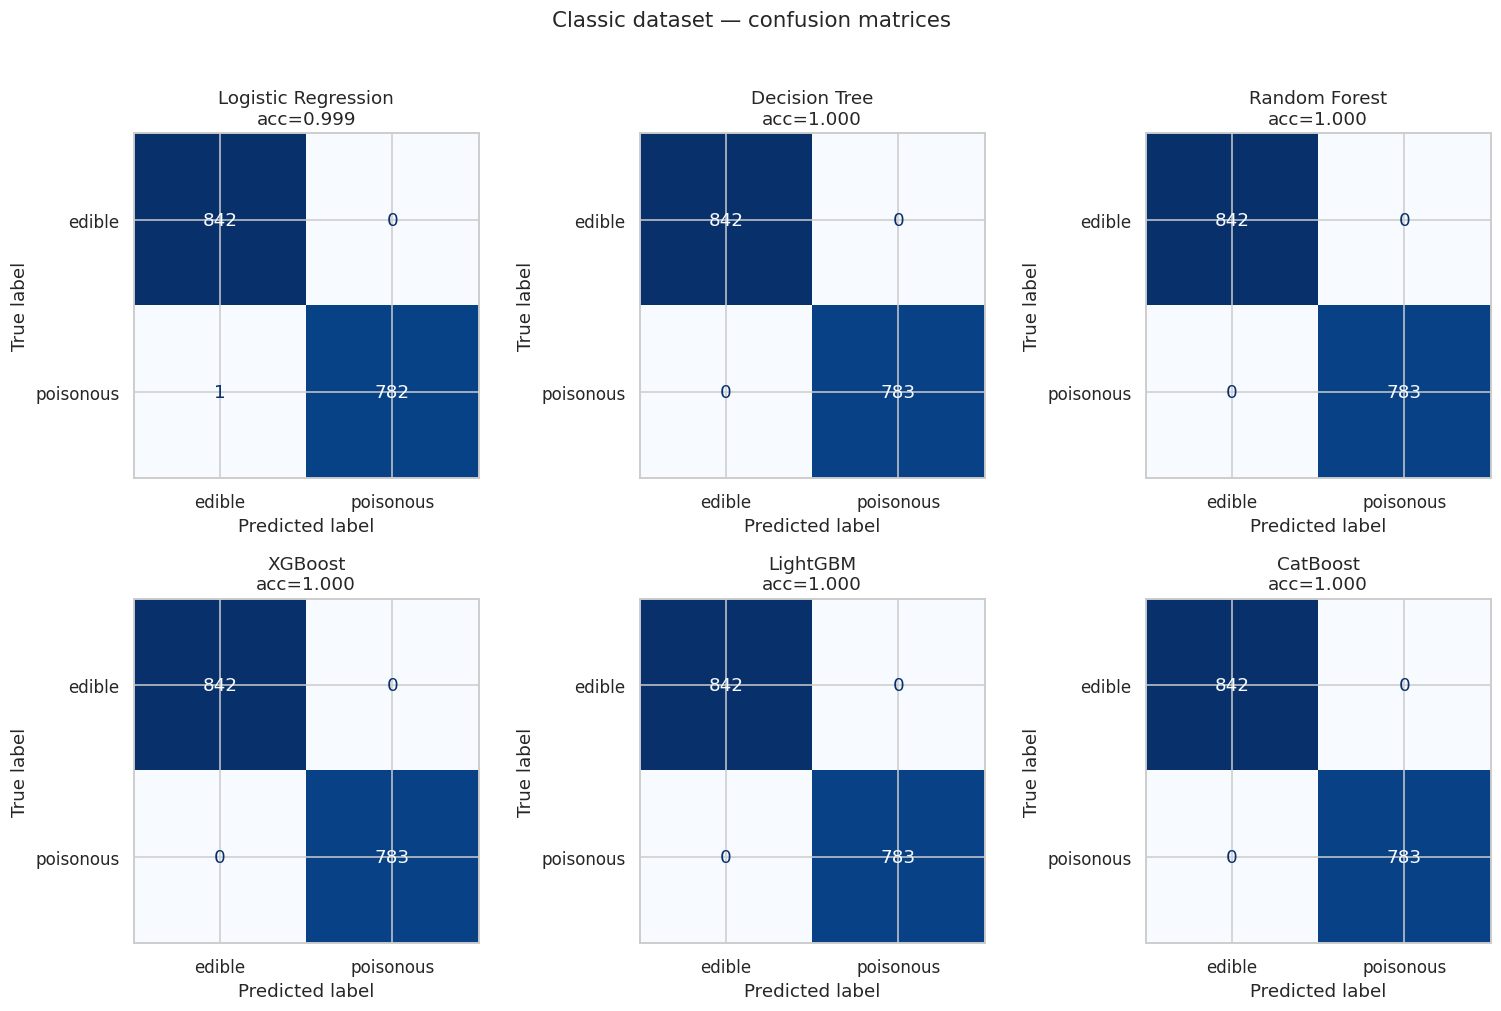

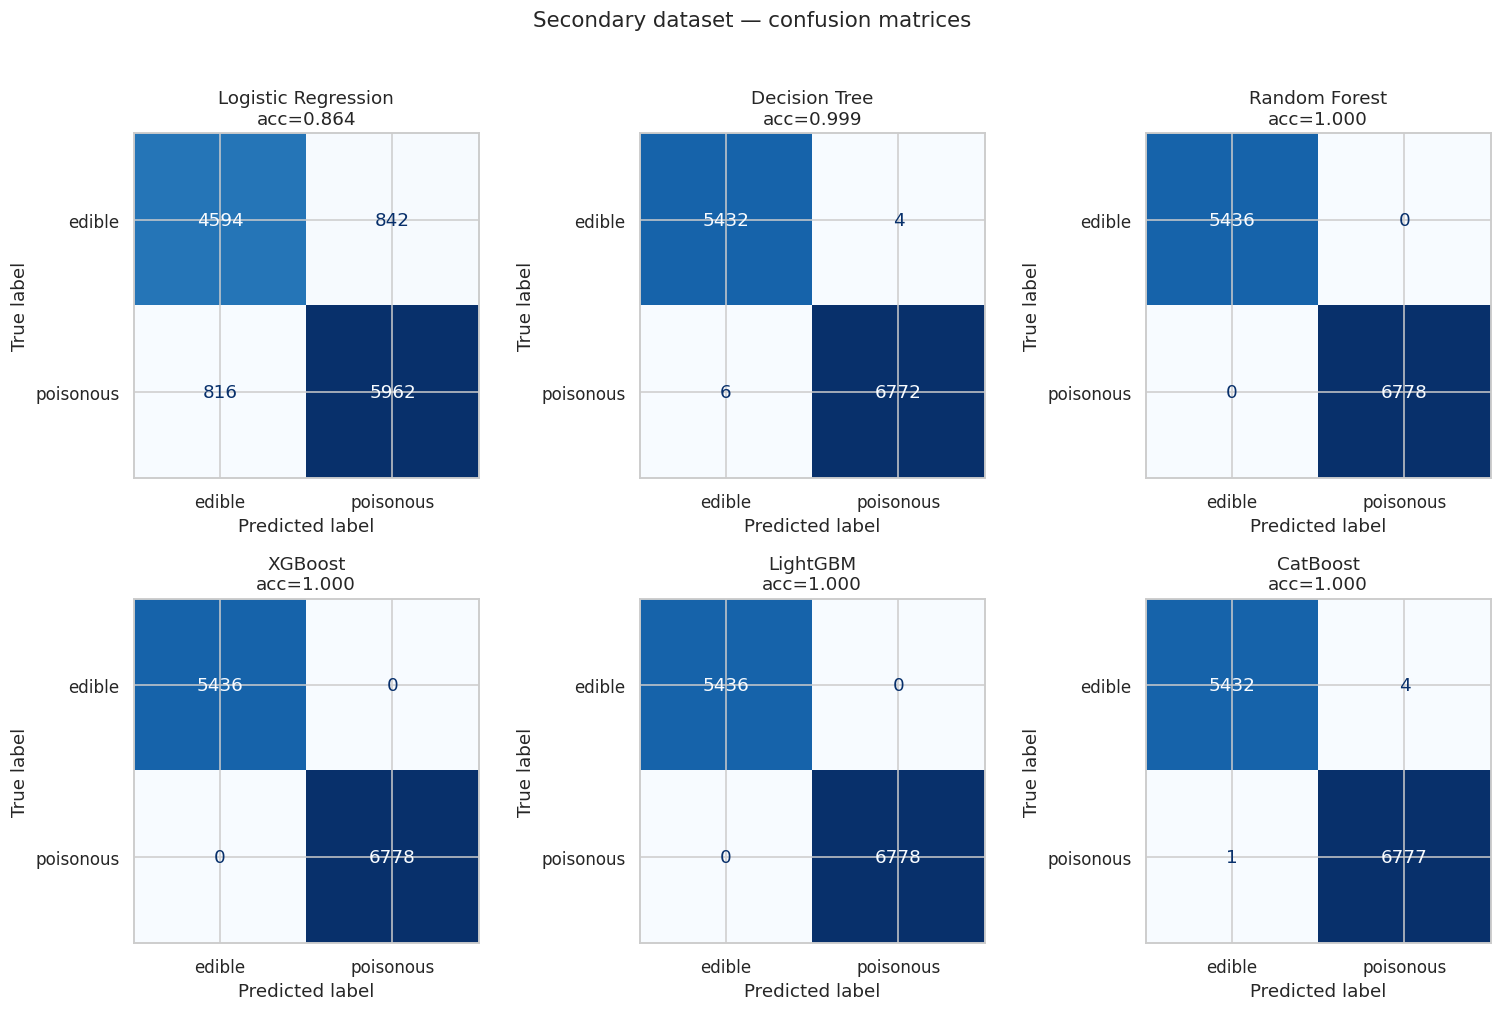

In [5]:
for dsname, b in bench.items():
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for ax, res in zip(axes.ravel(), b["results"]):
        cm = res["confusion_matrix"]
        ConfusionMatrixDisplay(cm, display_labels=["edible", "poisonous"]).plot(
            ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f'{res["model"]}\nacc={res["accuracy"]:.3f}')
    plt.suptitle(f"{dsname} dataset — confusion matrices", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


## ROC curves

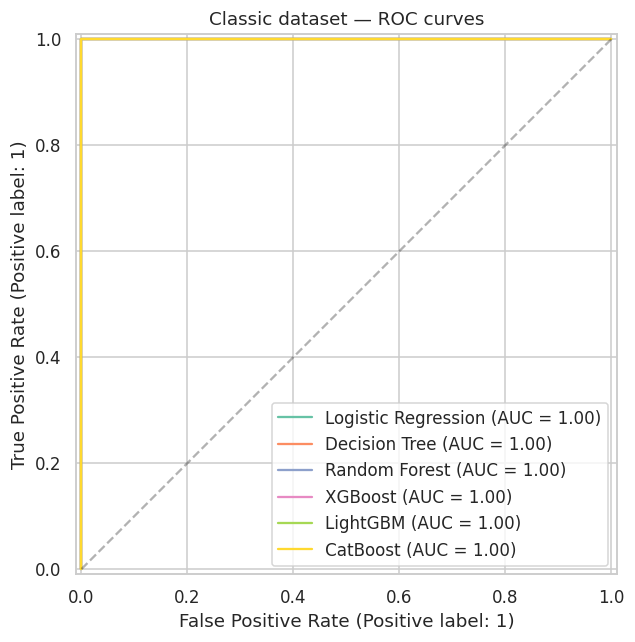

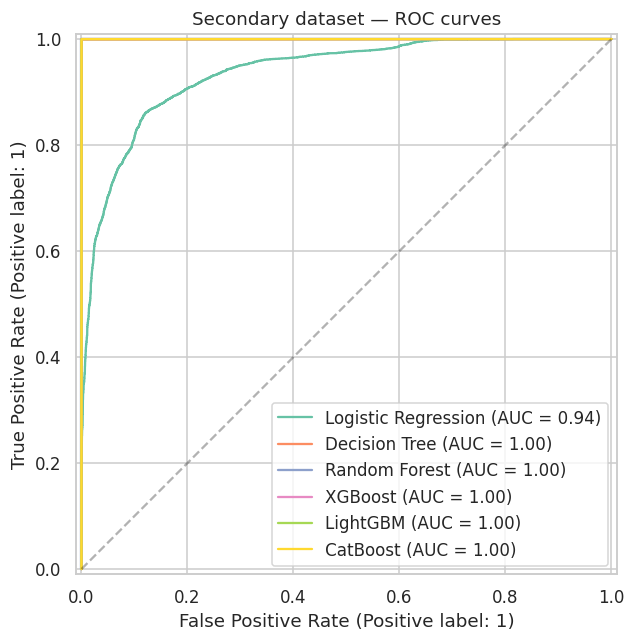

In [6]:
for dsname, b in bench.items():
    plt.figure(figsize=(6.5, 6))
    ax = plt.gca()
    for name, model in b["models"].items():
        X_eval = b["Xc_test"] if name == "CatBoost" else b["X_test"]
        y_bin = (b["y_test"] == "poisonous").astype(int)
        scores = ml.get_scores(model, X_eval)
        RocCurveDisplay.from_predictions(y_bin, scores, name=name, ax=ax)
    plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
    plt.title(f"{dsname} dataset — ROC curves")
    plt.tight_layout()
    plt.show()


## Feature importance / coefficients

Top drivers for a linear model (Logistic Regression), a single interpretable tree
(Decision Tree), and the strongest ensemble (Random Forest) on each dataset.

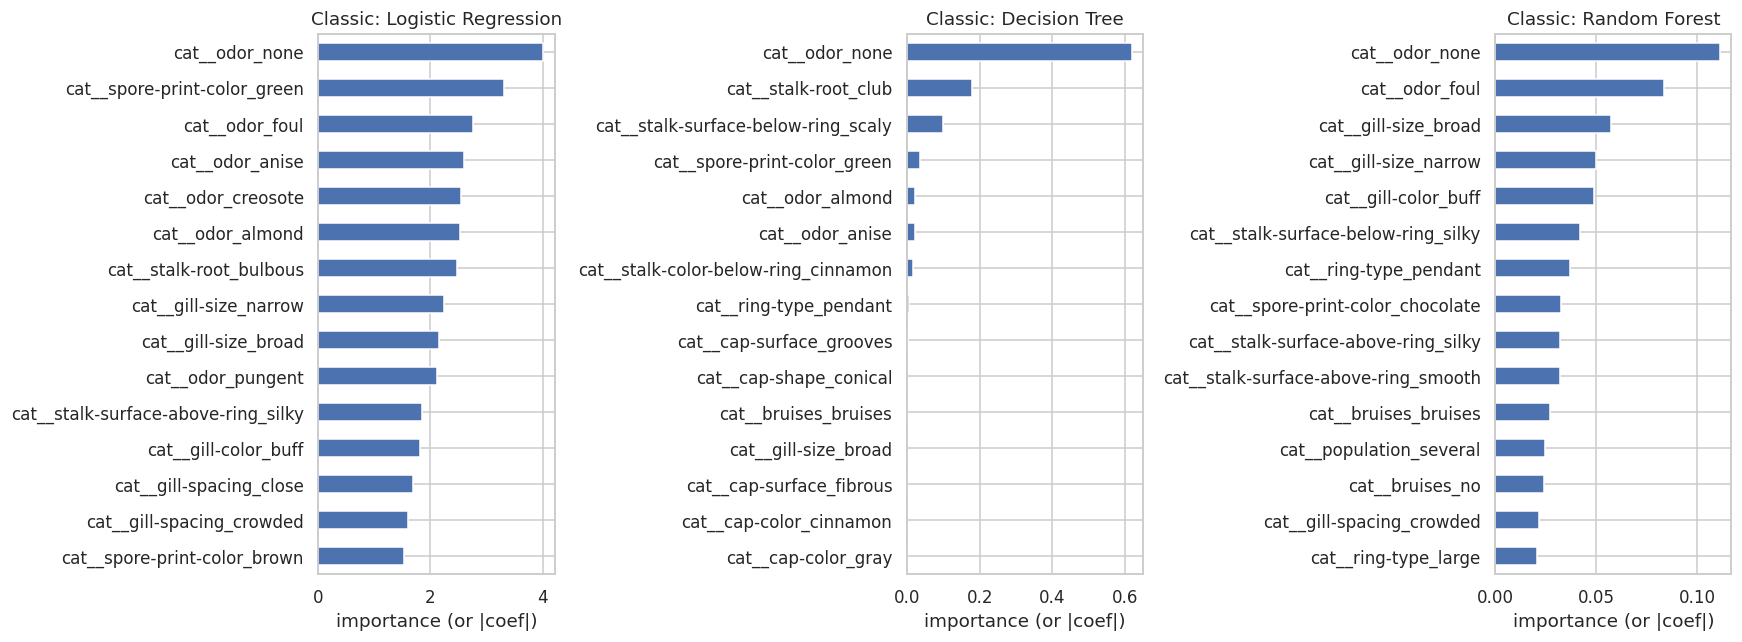

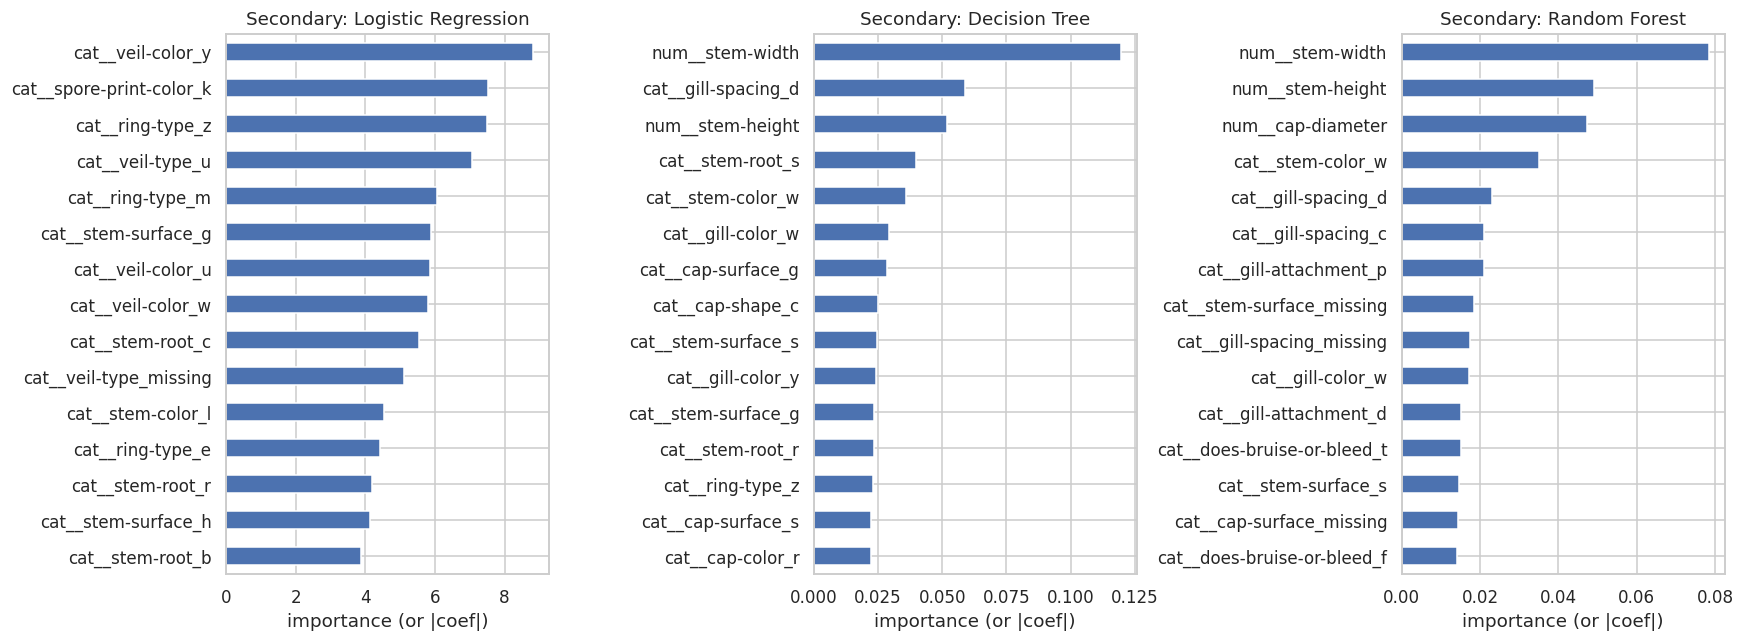

In [7]:
def top_importances(model, feature_names, n=15):
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=feature_names)
    elif hasattr(model, "coef_"):
        imp = pd.Series(np.abs(model.coef_[0]), index=feature_names)
    else:
        return None
    return imp.sort_values(ascending=False).head(n)


for dsname, b in bench.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    for ax, mname in zip(axes, ["Logistic Regression", "Decision Tree", "Random Forest"]):
        top = top_importances(b["models"][mname], b["feature_names"])
        top.iloc[::-1].plot.barh(ax=ax, color="#4C72B0")
        ax.set_title(f"{dsname}: {mname}")
        ax.set_xlabel("importance (or |coef|)")
    plt.tight_layout()
    plt.show()


**Classic dataset:** `odor` categories dominate every model type — consistent with the
EDA finding that odor alone is close to a lookup table for this dataset.

**Secondary dataset:** with no `odor` feature, importance spreads across `stem-width`,
`cap-diameter`, `stem-color`, `gill-color`, and several ring/spore-print categories — no single
feature dominates the way `odor` does in the classic set, matching the EDA expectation that
this dataset requires combining several weaker signals.

## Phase 4 — Cross-dataset benchmark comparison

Now put the two datasets' results side by side to directly answer the project's central
question: how does model performance, cost, and behavior change moving from the small
classic dataset to the much larger, harder secondary dataset?

In [8]:
combined = pd.concat(
    {dsname: ml.results_to_frame(b["results"]) for dsname, b in bench.items()},
    axis=0
)
combined.index.names = ["dataset", "model"]
combined.round(4)


accuracy  precision  recall      f1  roc_auc  \
dataset   model                                                               
Classic   Logistic Regression    0.9994     1.0000  0.9987  0.9994   1.0000   
          Decision Tree          1.0000     1.0000  1.0000  1.0000   1.0000   
          Random Forest          1.0000     1.0000  1.0000  1.0000   1.0000   
          XGBoost                1.0000     1.0000  1.0000  1.0000   1.0000   
          LightGBM               1.0000     1.0000  1.0000  1.0000   1.0000   
          CatBoost               1.0000     1.0000  1.0000  1.0000   1.0000   
Secondary Logistic Regression    0.8643     0.8762  0.8796  0.8779   0.9369   
          Decision Tree          0.9992     0.9994  0.9991  0.9993   0.9992   
          Random Forest          1.0000     1.0000  1.0000  1.0000   1.0000   
          XGBoost                1.0000     1.0000  1.0000  1.0000   1.0000   
          LightGBM               1.0000     1.0000  1.0000  1.0000   1.0000   
          CatBoost               0.9996     0.9994  0.9999  0.9996   1.0000   

                               cv_accuracy_mean  cv_f1_mean  cv_roc_auc_mean  \
dataset   model                                                                
Classic   Logistic Regression            0.9994      0.9994           1.0000   
          Decision Tree                  0.9997      0.9997           0.9997   
          Random Forest                  1.0000      1.0000           1.0000   
          XGBoost                        1.0000      1.0000           1.0000   
          LightGBM                       1.0000      1.0000           1.0000   
          CatBoost                       0.9997      0.9997           1.0000   
Secondary Logistic Regression            0.8661      0.8785           0.9367   
          Decision Tree                  0.9987      0.9988           0.9987   
          Random Forest                  1.0000      1.0000           1.0000   
          XGBoost                        1.0000      1.0000           1.0000   
          LightGBM                       1.0000      1.0000           1.0000   
          CatBoost                       0.9997      0.9997           1.0000   

                               train_time_s  predict_time_s  
dataset   model                                              
Classic   Logistic Regression        0.0146          0.0002  
          Decision Tree              0.0126          0.0004  
          Random Forest              0.5020          0.0180  
          XGBoost                    0.0765          0.0037  
          LightGBM                   0.1211          0.0090  
          CatBoost                   1.1091          0.0074  
Secondary Logistic Regression        0.4047          0.0008  
          Decision Tree              0.8065          0.0021  
          Random Forest             21.2119          0.1676  
          XGBoost                    0.7893          0.0714  
          LightGBM                   1.0517          0.1521  
          CatBoost                   6.8281          0.0431

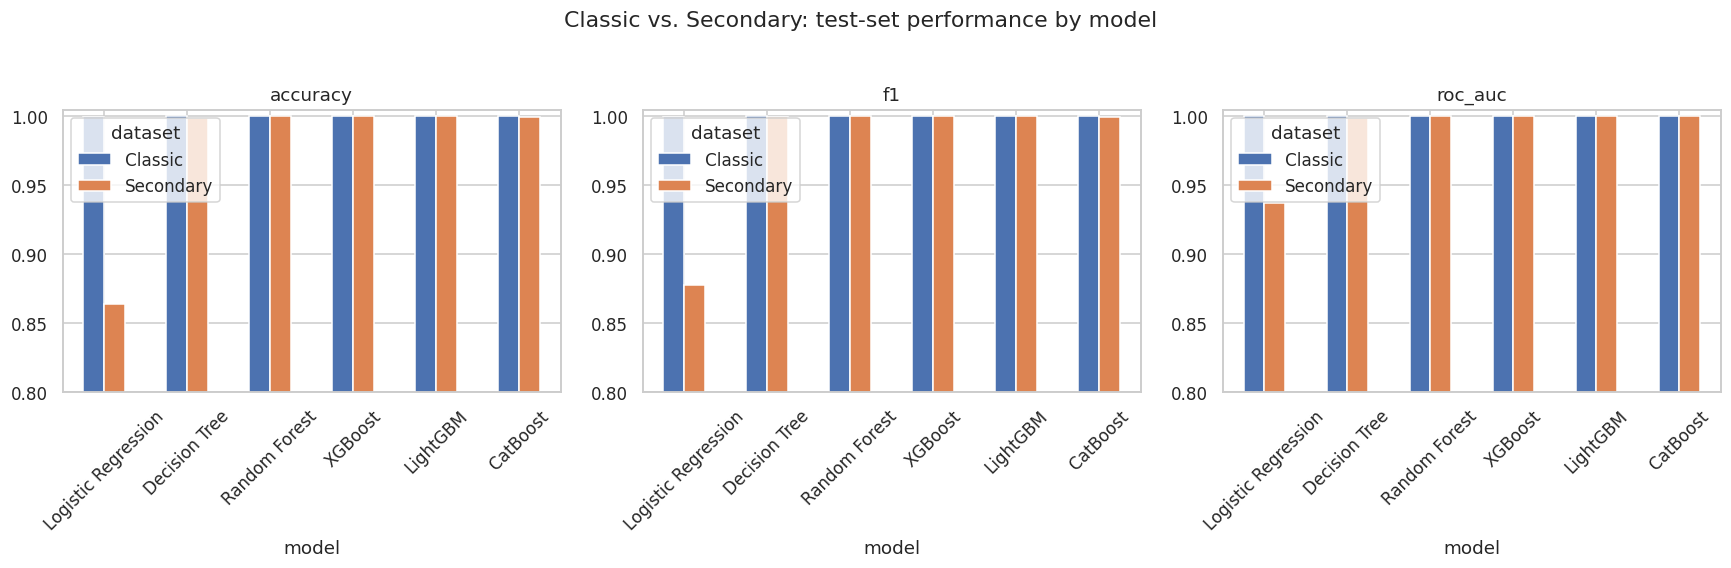

In [9]:
metrics_to_plot = ["accuracy", "f1", "roc_auc"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, metrics_to_plot):
    plot_df = combined[metric].unstack("dataset")
    plot_df.plot.bar(ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(metric)
    ax.set_ylim(0.8, 1.005)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Classic vs. Secondary: test-set performance by model", y=1.03)
plt.tight_layout()
plt.show()


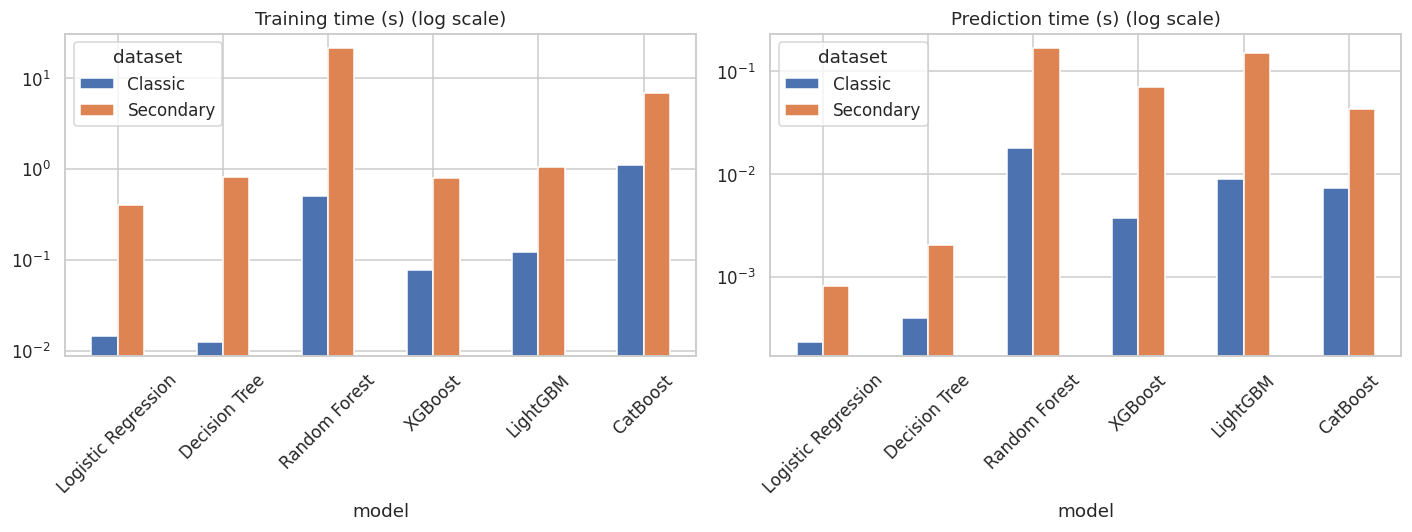

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes, ["train_time_s", "predict_time_s"],
                              ["Training time (s)", "Prediction time (s)"]):
    plot_df = combined[metric].unstack("dataset")
    plot_df.plot.bar(ax=ax, color=["#4C72B0", "#DD8452"], logy=True)
    ax.set_title(title + " (log scale)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**Key comparison takeaways:**

- **Performance**: nearly every model reaches 99–100% accuracy/F1/ROC-AUC on the *classic*
  dataset — largely because `odor` makes it close to a solved problem. On the *secondary*
  dataset, Logistic Regression drops noticeably (it can't capture the nonlinear interactions
  needed without `odor`), while tree-based and boosting models still reach ~99.9–100%. This
  is strong evidence that **the secondary dataset is the more realistic, harder benchmark**,
  and that nonlinear models earn their keep here in a way they don't on the classic set.
- **Cost**: training time scales with dataset size roughly as expected — Random Forest and
  CatBoost are markedly slower on the ~61k-row secondary dataset than on the ~8k-row classic
  one, while XGBoost/LightGBM stay comparatively fast at both scales, making them attractive
  choices as the dataset grows.
- **Simplicity vs. performance**: the Decision Tree is only marginally behind the ensembles
  on both datasets, and — unlike them — its rules are directly human-readable. That trade-off
  is explored further in the explainability notebook.
